# Read Label Tif Files
This notebook contains code to read in and load a particular label tif file, which helps to understand what values are in the particular file. To use this notebook, enter the relative path of the .tif file of interest into FILE_PATH and run both code cells. 

Note the FILE_PATH has to be the relative path to the file. Example:  `../data/dataset/labels/114_5062566_2019.06.14_JL.tif`

In [32]:
FILE_PATH="../data/dataset/labels/114_5062566_2019.06.14_JL.tif"

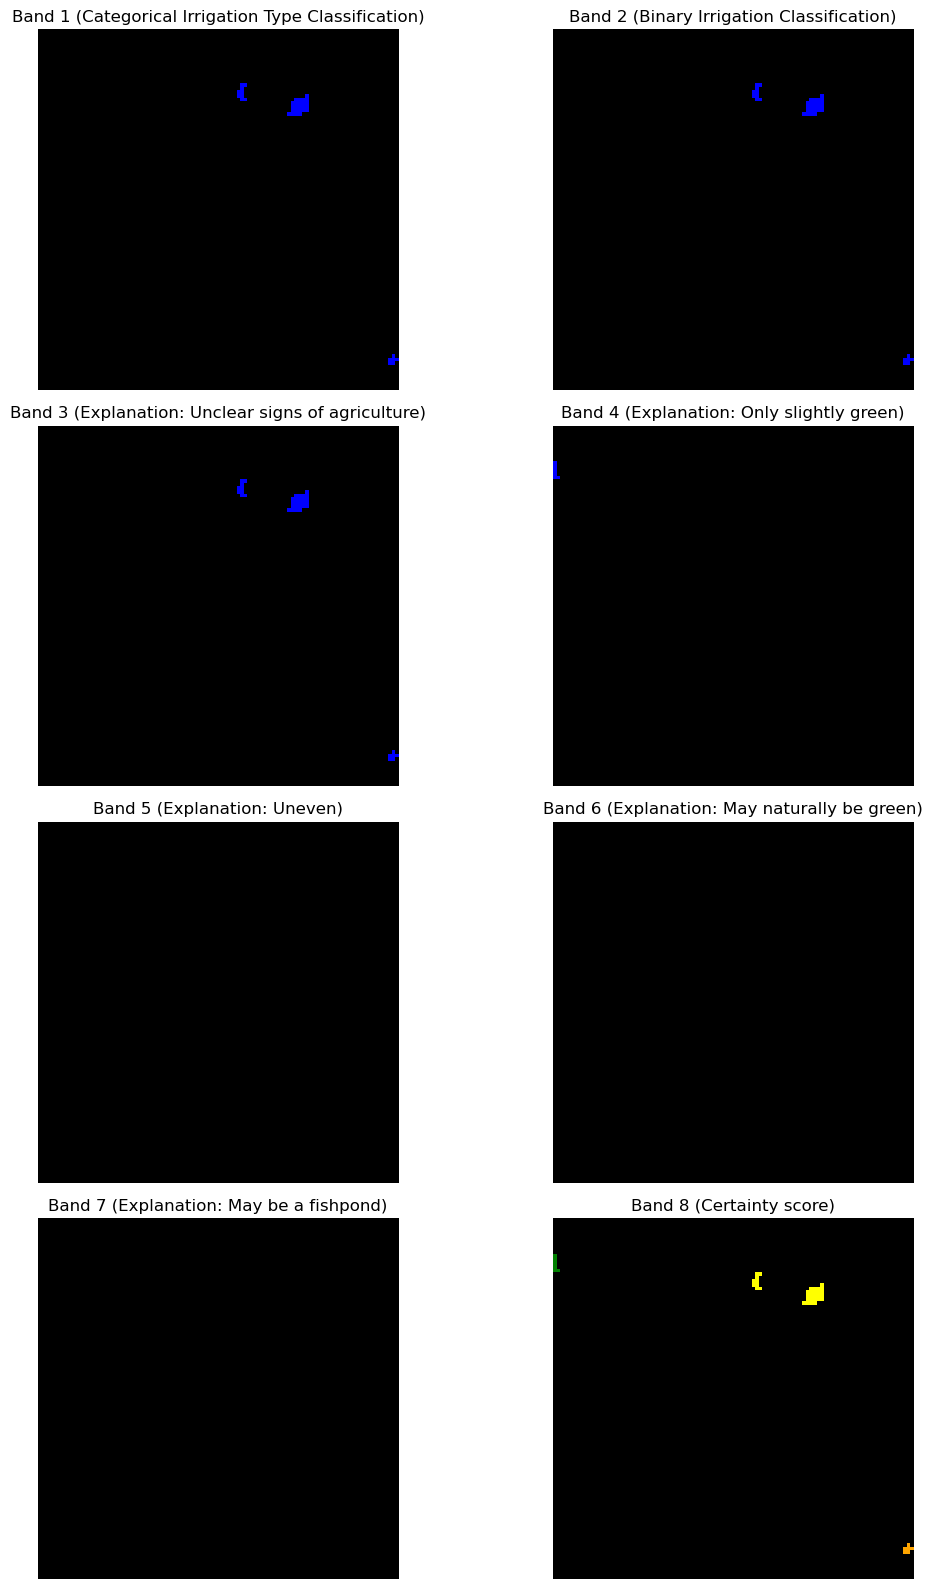

In [33]:
import tifffile
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Define discrete colormap for class values (e.g., 0–5)
colors = ['black', 'blue', 'green', 'yellow', 'orange', 'red']
cmap = ListedColormap(colors)

# Load TIF file
with tifffile.TiffFile(FILE_PATH) as tif:
    image = tif.asarray()

# Ensure shape is (8, 100, 100)
if image.shape[-1] == 8:
    image = np.transpose(image, (2, 0, 1))

# Create a 4x2 grid for plotting 8 bands
fig, axes = plt.subplots(4, 2, figsize=(12, 16))  # Width x Height in inches
axes = axes.flatten()

band_dict = {
    1: "Categorical Irrigation Type Classification",
    2: "Binary Irrigation Classification",
    3: "Explanation: Unclear signs of agriculture",
    4: "Explanation: Only slightly green",
    5: "Explanation: Uneven",
    6: "Explanation: May naturally be green",
    7: "Explanation: May be a fishpond",
    8: "Certainty score"
}

# Plot each band
for i in range(8):
    ax = axes[i]
    ax.imshow(image[i], cmap=cmap, vmin=0, vmax=len(colors) - 1)
    ax.set_title(f'Band {i + 1} ({band_dict[i+1]})', fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()
